# Representation Analysis — sprite world

An asymmetric **arrow** sprite with pose **(x, y, θ)** on a 64×64 canvas. Four
runs share identical dynamics (all DOFs move); only the controllable DOFs in the
action vector change.

| Run | controlled DOFs | action_dim |
|-----|-----------------|-----------:|
| `none` | —            | 0 |
| `x`    | x            | 1 |
| `xy`   | x, y         | 2 |
| `xyt`  | x, y, θ      | 3 |

In [9]:
import sys
from pathlib import Path

CWD = Path(".").resolve()
EXPERIMENT_DIR = CWD if (CWD / "config_xyt.yaml").exists() \
                 else CWD / "experiments" / "sprite_decoder"
REPO_ROOT = EXPERIMENT_DIR.parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from misc.plot_style import FULL_WIDTH, HALF_WIDTH, palette, apply_matplotlib_style, figure_size
apply_matplotlib_style()

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
import torch
import yaml

RUNS = ["none", "x", "xy", "xyt"]
RESULTS_DIR = EXPERIMENT_DIR / "results"

# Per-run controllable DOFs, colors, and expected latent dim (θ counts as 2).
DOF_NAMES   = ["x", "y", "θ"]
CONTROLLED  = {"none": set(), "x": {"x"}, "xy": {"x", "y"}, "xyt": {"x", "y", "θ"}}
EXPECTED_DIM = {"none": 0, "x": 1, "xy": 2, "xyt": 4}
RUN_COLOR = {
    "none": palette["Dark Grey"],
    "x":    palette["Dark Blue"],
    "xy":   palette["Med Purple"],
    "xyt":  palette["Dark Red"],
}

results = {}
for run in RUNS:
    run_dir = RESULTS_DIR / run
    if (run_dir / "embeddings.pt").exists():
        results[run] = {
            "history":    torch.load(run_dir / "train_history.pt", map_location="cpu", weights_only=False),
            "embeddings": torch.load(run_dir / "embeddings.pt",    map_location="cpu", weights_only=False),
        }
        with open(run_dir / "config.yaml") as f:
            results[run]["cfg"] = yaml.safe_load(f)
        print(f"  loaded {run}")
    else:
        print(f"  [missing] {run}  (run train.py with config_{run}.yaml)")

RUNS = [r for r in RUNS if r in results]
HAS_RESULTS = len(RUNS) > 0
SMOOTH_W = 5

  loaded none
  loaded x
  loaded xy
  loaded xyt


In [11]:
def to_numpy(x):
    return x.detach().cpu().numpy() if isinstance(x, torch.Tensor) else np.asarray(x)

def smooth(v, w=SMOOTH_W):
    return pd.Series(np.asarray(v, dtype=float)).rolling(w, min_periods=1).mean().to_numpy()

def pca_eigvals(Z, eps=1e-12):
    Zc = Z - Z.mean(axis=0)
    _, S, _ = np.linalg.svd(Zc, full_matrices=False)
    return np.maximum((S ** 2) / max(1, Z.shape[0] - 1), eps)

def effective_rank(eigvals, eps=1e-12):
    e = eigvals[eigvals > eps]
    if e.size == 0:
        return 1.0
    p = e / e.sum()
    return float(np.exp(-(p * np.log(p)).sum()))

def pca_2d(Z):
    Zc = Z - Z.mean(axis=0)
    _, S, Vt = np.linalg.svd(Zc, full_matrices=False)
    scores = Zc @ Vt[:2].T
    evr = (S ** 2) / max(1, Z.shape[0] - 1)
    evr = evr / np.maximum(evr.sum(), 1e-12)
    return scores, evr[:2]

def snapshot_metrics(snap):
    Z = np.concatenate([to_numpy(snap["z_t"]), to_numpy(snap["z_tp1"])], axis=0)
    ev = pca_eigvals(Z)
    return {
        "z_l2":       float(np.linalg.norm(Z, axis=1).mean()),
        "z_std":      float(Z.std(axis=0, ddof=0).mean()),
        "z_eff_rank": effective_rank(ev),
        "mean_z_l2":  float(np.linalg.norm(Z.mean(axis=0))),
        "eigvals":    ev,
    }

def linear_probe_r2(Z, Y, seed=0, frac_train=0.5):
    """Held-out R^2 of a linear readout Z -> Y (mean over target columns)."""
    Z = np.asarray(Z, float); Y = np.asarray(Y, float)
    if Y.ndim == 1:
        Y = Y[:, None]
    N = Z.shape[0]
    idx = np.random.default_rng(seed).permutation(N)
    k = max(1, int(N * frac_train))
    tr, te = idx[:k], idx[k:]
    A = np.column_stack([Z, np.ones(N)])
    W, *_ = np.linalg.lstsq(A[tr], Y[tr], rcond=None)
    pred = A[te] @ W
    ss_res = ((Y[te] - pred) ** 2).sum(axis=0)
    ss_tot = ((Y[te] - Y[te].mean(axis=0)) ** 2).sum(axis=0)
    return float(np.mean(1.0 - ss_res / np.maximum(ss_tot, 1e-12)))

def final_embeddings(run):
    """Final-snapshot z_t and aligned true state (x, y, θ)."""
    emb = results[run]["embeddings"]
    last = max(emb["snapshots"])
    z = to_numpy(emb["snapshots"][last]["z_t"])
    pos = to_numpy(emb["positions"]).reshape(z.shape[0], -1)   # (N, 3) = (x, y, θ)
    return z, pos

def dof_targets(pos):
    """Regression targets per DOF; θ -> (cos, sin) so it is not wrapped."""
    return {"x": pos[:, 0], "y": pos[:, 1],
            "θ": np.column_stack([np.cos(pos[:, 2]), np.sin(pos[:, 2])])}

if HAS_RESULTS:
    metrics = {
        run: {int(e): snapshot_metrics(s) for e, s in data["embeddings"]["snapshots"].items()}
        for run, data in results.items()
    }

## 1 — Loss curves

Forward / inverse / total; train (faint) vs eval (solid). `none` has no inverse term.

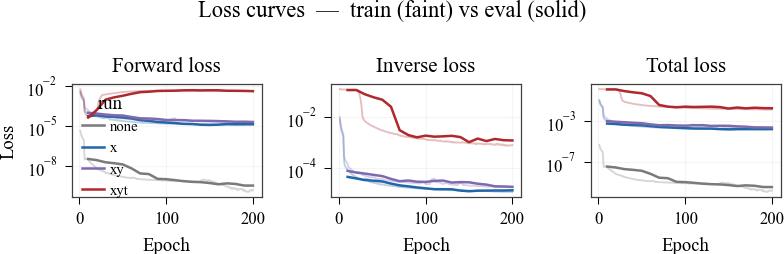

In [12]:
if not HAS_RESULTS:
    print("No results. Run train.py with the config_*.yaml files first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=figure_size(FULL_WIDTH, ratio=0.34))
    for ax, key, title in zip(axes, ["fwd", "inv", "total"], ["Forward", "Inverse", "Total"]):
        for run in RUNS:
            tr, ev = results[run]["history"]["train"], results[run]["history"]["eval"]
            if np.any(np.asarray(tr[key]) > 0):                      # 'none' has no inverse loss
                ax.semilogy(tr["epoch"], smooth(tr[key]), color=RUN_COLOR[run], alpha=0.3, linewidth=0.9)
            if np.any(np.asarray(ev[key]) > 0):
                ax.semilogy(ev["epoch"], smooth(ev[key]), color=RUN_COLOR[run], label=run)
        ax.set_title(f"{title} loss")
        ax.set_xlabel("Epoch")
        ax.grid(True, which="both", alpha=0.3)
    axes[0].set_ylabel("Loss")
    axes[0].legend(title="run", frameon=False, fontsize=7)
    fig.suptitle("Loss curves  —  train (faint) vs eval (solid)")
    fig.tight_layout()
    plt.show()

## 2 — Latent geometry over training

Collapse monitoring; expect `none` to collapse (effective rank → 1).

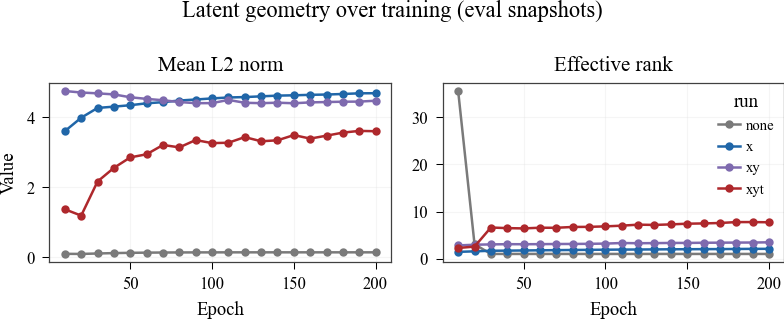

In [13]:
if not HAS_RESULTS:
    print("No results.")
else:
    specs = [("z_l2", "Mean L2 norm"), ("z_eff_rank", "Effective rank")]
    fig, axes = plt.subplots(1, 2, figsize=figure_size(FULL_WIDTH, ratio=0.42))
    for ax, (key, title) in zip(axes, specs):
        for run in RUNS:
            eps = sorted(metrics[run])
            ax.plot(eps, [metrics[run][e][key] for e in eps], "o-",
                    color=RUN_COLOR[run], label=run, markersize=3)
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("Value")
    axes[1].legend(title="run", fontsize=7, frameon=False)
    fig.suptitle("Latent geometry over training (eval snapshots)")
    fig.tight_layout()
    plt.show()

## 3 — Final PCA spectra

Top-PC explained-variance ratio; dashed line = expected controllable dim (θ counts as 2).

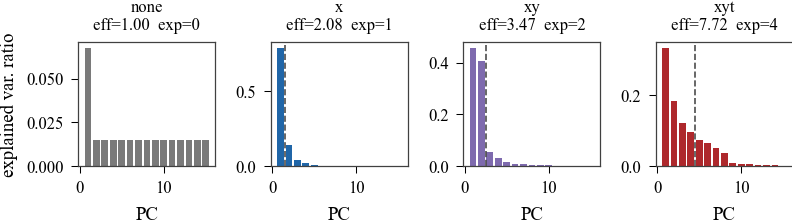

In [14]:
if not HAS_RESULTS:
    print("No results.")
else:
    K = 15
    fig, axes = plt.subplots(1, len(RUNS), figsize=figure_size(FULL_WIDTH, ratio=0.32), squeeze=False)
    for ax, run in zip(axes[0], RUNS):
        last = max(metrics[run])
        ev = metrics[run][last]["eigvals"]
        evr = ev / ev.sum()
        ax.bar(np.arange(1, K + 1), evr[:K], color=RUN_COLOR[run])
        if EXPECTED_DIM[run] > 0:
            ax.axvline(EXPECTED_DIM[run] + 0.5, ls="--", lw=0.8, color="0.3")
        ax.set_title(f"{run}\neff={metrics[run][last]['z_eff_rank']:.2f}  exp={EXPECTED_DIM[run]}", fontsize=8)
        ax.set_xlabel("PC")
    axes[0][0].set_ylabel("explained var. ratio")
    fig.tight_layout()
    plt.show()

## 4 — PC1 × PC2 colored by each DOF

Red frame = DOF uncontrolled in that run.

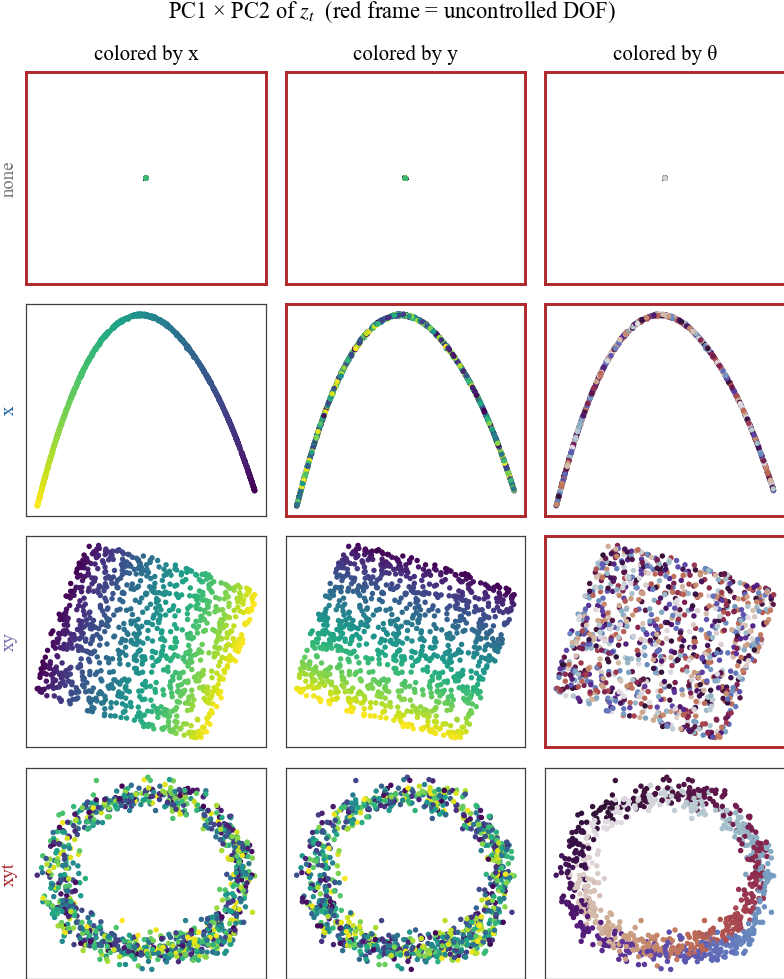

In [15]:
if not HAS_RESULTS:
    print("No results.")
else:
    cmaps = {"x": "viridis", "y": "viridis", "θ": "twilight"}
    fig, axes = plt.subplots(len(RUNS), 3, figsize=figure_size(FULL_WIDTH, height=1.7 * len(RUNS)), squeeze=False)
    for row, run in enumerate(RUNS):
        z, pos = final_embeddings(run)
        scores, evr = pca_2d(z)
        coloring = {"x": pos[:, 0], "y": pos[:, 1], "θ": pos[:, 2]}
        for col, dof in enumerate(DOF_NAMES):
            ax = axes[row][col]
            ax.scatter(scores[:, 0], scores[:, 1], c=coloring[dof], cmap=cmaps[dof], s=4)
            ax.set_xticks([]); ax.set_yticks([])
            if dof not in CONTROLLED[run]:                 # red frame = uncontrolled DOF
                for sp in ax.spines.values():
                    sp.set_color(palette["Dark Red"]); sp.set_linewidth(1.4)
            if row == 0:
                ax.set_title(f"colored by {dof}")
            if col == 0:
                ax.set_ylabel(run, color=RUN_COLOR[run])
    fig.suptitle("PC1 × PC2 of $z_t$  (red frame = uncontrolled DOF)")
    fig.tight_layout()
    plt.show()

## 5 — Per-DOF decodability (linear probe)

Held-out R² of a linear readout `z_t → DOF` (θ via cos/sin); box = controllable.

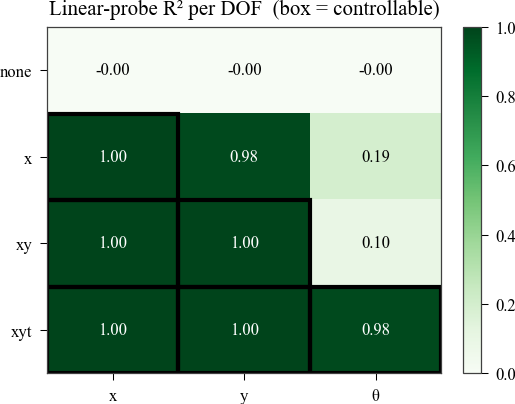

In [16]:
if not HAS_RESULTS:
    print("No results.")
else:
    R2 = np.zeros((len(RUNS), 3))
    for i, run in enumerate(RUNS):
        z, pos = final_embeddings(run)
        tgt = dof_targets(pos)
        R2[i] = [linear_probe_r2(z, tgt[d]) for d in DOF_NAMES]

    fig, ax = plt.subplots(figsize=figure_size(HALF_WIDTH * 1.4, ratio=0.8))
    im = ax.imshow(np.clip(R2, 0, 1), vmin=0, vmax=1, cmap="Greens", aspect="auto")
    ax.set_xticks(range(3), DOF_NAMES); ax.set_yticks(range(len(RUNS)), RUNS)
    for i, run in enumerate(RUNS):
        for j, dof in enumerate(DOF_NAMES):
            ax.text(j, i, f"{R2[i, j]:.2f}", ha="center", va="center",
                    color="white" if R2[i, j] > 0.6 else "black", fontsize=8)
            if dof in CONTROLLED[run]:
                ax.add_patch(Rectangle((j - .5, i - .5), 1, 1, fill=False, ec="k", lw=2))
    ax.set_title("Linear-probe R² per DOF  (box = controllable)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    plt.show()